# Blue Archive ガチャシミュレーション — 関数型リファクタリング版

この版では、次の制約を満たすように設計しています。

- 関数内でグローバル変数を参照しない
- 関数内でグローバル変数を書き換えない
- `State` を直接変更しない
- すべての状態変更は、新しい `State` を `return` して表現する
- 乱数生成器も関数へ明示的に渡す
- 終了条件・切替条件も関数として明示的に渡す

そのため、各関数の入力と出力を追えば処理全体をレビューできます。


In [55]:
# ============================================================
# 使用するライブラリを読み込みます。
# 通常はこのセルを変更せず、そのまま実行してください。
# ============================================================
from __future__ import annotations

from dataclasses import dataclass, replace
from enum import Enum, auto
from typing import Callable
import random
import statistics

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np


## 1. 設定・状態・抽選結果

In [3]:
# ============================================================
# ガチャ仕様とシミュレーション状態の定義です。
# 通常利用では、このセルを直接変更する必要はありません。
# ガチャ条件は後半の実行用セルで Config(...) に指定します。
# Configで省略した項目には、ここで定義された初期値が使われます。
# ============================================================
class GachaSystem(Enum):
    NEW = auto()
    OLD = auto()


class Banner(Enum):
    PU1 = auto()
    PU2 = auto()


class Draw(Enum):
    STAR1 = auto()
    STAR2 = auto()
    STAR3_OTHER = auto()
    PU1 = auto()
    PU2 = auto()


@dataclass(frozen=True)
class Config:
    system: GachaSystem = GachaSystem.NEW

    pickup_rate: float = 0.007
    # 引いているガチャと違うほうのピックアップが出る確率(星3確率を)
    other_pickup_rate: float = (0.03 - 0.007) / 112
    star3_rate: float = 0.03
    star2_or_higher_rate: float = 0.215

    initial_charge: int = 0
    initial_banner: Banner = Banner.PU1
    pulls_per_batch: int = 10

    charge_100_target_rate: float = 0.5
    charge_100_other_pickup_rate: float = 0.5 / 112
    charge_100: int = 100
    charge_200: int = 200

    # 旧方式: 200ポイントごとに対象PUを交換可能
    old_ceiling_points: int = 200

    def __post_init__(self) -> None:
        probabilities = (
            self.pickup_rate,
            self.other_pickup_rate,
            self.star3_rate,
            self.star2_or_higher_rate,
            self.charge_100_target_rate,
            self.charge_100_other_pickup_rate,
        )

        if not all(0.0 <= value <= 1.0 for value in probabilities):
            raise ValueError("All probabilities must be between 0 and 1.")

        if self.pickup_rate + self.other_pickup_rate > self.star3_rate:
            raise ValueError(
                "pickup_rate + other_pickup_rate must not exceed star3_rate."
            )

        if self.star3_rate > self.star2_or_higher_rate:
            raise ValueError(
                "star3_rate must not exceed star2_or_higher_rate."
            )

        if (
            self.charge_100_target_rate
            + self.charge_100_other_pickup_rate
            > 1.0
        ):
            raise ValueError(
                "charge_100_target_rate + "
                "charge_100_other_pickup_rate must not exceed 1."
            )

        if not 0 <= self.initial_charge < self.charge_200:
            raise ValueError(
                "initial_charge must satisfy 0 <= initial_charge < charge_200."
            )

        if self.pulls_per_batch <= 0:
            raise ValueError("pulls_per_batch must be positive.")

        if self.old_ceiling_points <= 0:
            raise ValueError("old_ceiling_points must be positive.")


@dataclass(frozen=True)
class State:
    pulls: int
    batches: int
    charge: int
    banner: Banner

    pu1: int
    pu2: int
    star3: int

    pu1_banner_pulls: int
    pu2_banner_pulls: int

    cost_pyroxene: int


@dataclass(frozen=True)
class TrialResult:
    state: State
    seed: int


## 2. 初期状態

In [4]:
# ============================================================
# 1回のシミュレーション開始時の状態を作成します。
# 通常は変更不要です。
# ============================================================
def create_initial_state(config: Config) -> State:
    return State(
        pulls=0,
        batches=0,
        charge=config.initial_charge,
        banner=config.initial_banner,
        pu1=0,
        pu2=0,
        star3=0,
        pu1_banner_pulls=0,
        pu2_banner_pulls=0,
        cost_pyroxene=0,
    )


## 3. 抽選ロジック

In [5]:
# ============================================================
# 1回ごとの抽選結果を決定する処理です。
# NEWでは100・200チャージの特典を判定し、OLDでは通常抽選を行います。
# 通常は変更不要です。
# ============================================================
def target_draw(banner: Banner) -> Draw:
    if banner is Banner.PU1:
        return Draw.PU1
    return Draw.PU2


def other_pickup_draw(banner: Banner) -> Draw:
    if banner is Banner.PU1:
        return Draw.PU2
    return Draw.PU1


def draw_normal(
    config: Config,
    banner: Banner,
    rng: random.Random,
) -> Draw:
    random_value = rng.random()

    if random_value < config.pickup_rate:
        return target_draw(banner)

    if random_value < config.pickup_rate + config.other_pickup_rate:
        return other_pickup_draw(banner)

    if random_value < config.star3_rate:
        return Draw.STAR3_OTHER

    if random_value < config.star2_or_higher_rate:
        return Draw.STAR2

    return Draw.STAR1


def draw_charge_100(
    config: Config,
    banner: Banner,
    rng: random.Random,
) -> Draw:
    random_value = rng.random()

    if random_value < config.charge_100_target_rate:
        return target_draw(banner)

    if random_value < config.charge_100_target_rate + config.charge_100_other_pickup_rate:
        return other_pickup_draw(banner)

    return Draw.STAR3_OTHER


def draw_one(
    config: Config,
    state: State,
    rng: random.Random,
) -> Draw:
    if config.system is GachaSystem.OLD:
        return draw_normal(
            config=config,
            banner=state.banner,
            rng=rng,
        )

    next_charge = state.charge + 1

    if next_charge == config.charge_200:
        return target_draw(state.banner)

    if next_charge == config.charge_100:
        return draw_charge_100(
            config=config,
            banner=state.banner,
            rng=rng,
        )

    return draw_normal(
        config=config,
        banner=state.banner,
        rng=rng,
    )


## 4. 抽選結果を新しい状態へ変換

In [74]:
# ============================================================
# 抽選結果をPU人数・星3人数・連数・青輝石コストへ反映します。
# NEWの募集チケット特典もこの処理で青輝石コストから差し引きます。
# 通常は変更不要です。
# ============================================================
def is_star3(result: Draw) -> bool:
    return result in {
        Draw.STAR3_OTHER,
        Draw.PU1,
        Draw.PU2,
    }


def is_current_banner_pickup(
    banner: Banner,
    result: Draw,
) -> bool:
    return (
        banner is Banner.PU1
        and result is Draw.PU1
    ) or (
        banner is Banner.PU2
        and result is Draw.PU2
    )


def is_getting_gacha_tichet(pulls: int) -> bool:
    return pulls in {70, 130, 150, 170, 270, 330, 350, 370}

def apply_draw(
    config: Config,
    state: State,
    result: Draw,
) -> State:
    next_charge = state.charge + 1

    if (
        config.system is GachaSystem.NEW
        and is_current_banner_pickup(state.banner, result)
    ):
        next_charge = 0

    next_pulls = state.pulls + 1

    next_cost_pyroxene = state.cost_pyroxene + 120

    if (
        config.system is GachaSystem.NEW
        and is_getting_gacha_tichet(next_pulls)
        ):
            next_cost_pyroxene = next_cost_pyroxene - 1200

    return replace(
        state,
        pulls=next_pulls,
        charge=next_charge,
        pu1=state.pu1 + int(result is Draw.PU1),
        pu2=state.pu2 + int(result is Draw.PU2),
        star3=state.star3 + int(is_star3(result)),
        pu1_banner_pulls=(
            state.pu1_banner_pulls
            + int(state.banner is Banner.PU1)
        ),
        pu2_banner_pulls=(
            state.pu2_banner_pulls
            + int(state.banner is Banner.PU2)
        ),
        cost_pyroxene = next_cost_pyroxene,
    )


## 5. まとめ引き

In [7]:
# ============================================================
# Configの pulls_per_batch で指定した回数をまとめて抽選します。
# 10連単位で試す場合は、実行用セルで pulls_per_batch=10 を指定します。
# 通常は変更不要です。
# ============================================================
def draw_batch(
    config: Config,
    state: State,
    rng: random.Random,
) -> State:
    next_state = replace(
        state,
        batches=state.batches + 1,
    )

    for _ in range(config.pulls_per_batch):
        result = draw_one(
            config=config,
            state=next_state,
            rng=rng,
        )

        next_state = apply_draw(
            config=config,
            state=next_state,
            result=result,
        )

    return next_state


`draw_batch` は受け取った `state` を変更しません。

各抽選ごとに新しい `State` を受け取り、最後の状態を `return` します。
まとめ引き中には終了条件やPU切替条件を評価しません。


## 6. 終了条件・切替条件

In [9]:
# ============================================================
# 終了条件とPU切替条件に利用できる補助関数です。
# 実際に使う条件は、後半の実行用セルで指定します。
# 独自条件は lambda state: ... の形式でも指定できます。
# ============================================================
Condition = Callable[[State], bool]


def stop_when_both_obtained(state: State) -> bool:
    return state.pu1 >= 1 and state.pu2 >= 1


def stop_when_luchey(state: State, luckey_threshold: int) -> bool:
    return state.pu1 >= 1 and state.pulls <= luckey_threshold


def stop_when_pu2_many_draw(state: State, pu2_draw_cnt: int) -> bool:
    return state.pu2_banner_pulls >= pu2_draw_cnt


def stop_when_pu1_or_pu2_obtained(state: State) -> bool:
    return state.pu1 >= 1 or state.pu2 >= 1


def switch_when_pu1_obtained(state: State) -> bool:
    return state.pu1 >= 1


## 7. PU切替

In [10]:
# ============================================================
# 指定した切替条件を満たした場合に、PU1募集からPU2募集へ切り替えます。
# 通常は変更不要です。
# ============================================================
def apply_banner_switch(
    state: State,
    switch_condition: Condition,
) -> State:
    should_switch = (
        state.banner is Banner.PU1
        and switch_condition(state)
    )

    if should_switch:
        return replace(
            state,
            banner=Banner.PU2,
        )

    return state


## 8. 1試行

In [64]:
# ============================================================
# OLD方式の終了時ポイント交換を行います。
# 200ポイントごとに、所持人数が少ないPUへ交換します。
# 通常は変更不要です。
# ============================================================
def exchange_old_points_at_end(
    config: Config,
    state: State,
) -> State:
    """旧方式の保有ポイントを終了時にまとめてPUへ交換する。

    200ポイントごとに1人交換し、その時点で所持数が少ないPUを選ぶ。
    PU1とPU2が同数の場合はPU1を選ぶ。
    """
    if config.system is not GachaSystem.OLD:
        return state

    exchange_count = state.charge // config.old_ceiling_points
    remaining_points = state.charge % config.old_ceiling_points

    next_pu1 = state.pu1
    next_pu2 = state.pu2

    for _ in range(exchange_count):
        if next_pu1 <= next_pu2:
            next_pu1 += 1
        else:
            next_pu2 += 1

    return State(
        pulls=state.pulls,
        batches=state.batches,
        charge=remaining_points,
        banner=state.banner,
        pu1=next_pu1,
        pu2=next_pu2,
        star3=state.star3 + exchange_count,
        pu1_banner_pulls=state.pu1_banner_pulls,
        pu2_banner_pulls=state.pu2_banner_pulls,
        cost_pyroxene=state.cost_pyroxene,
    )


In [12]:
# ============================================================
# 1試行分のシミュレーション本体です。
# 終了条件を満たすまでまとめ引きとPU切替を繰り返します。
# 通常は変更不要です。
# ============================================================
def simulate_once(
    config: Config,
    seed: int,
    stop_condition: Condition,
    switch_condition: Condition,
) -> TrialResult:
    rng = random.Random(seed)
    state = create_initial_state(config)

    while not stop_condition(state):
        state_after_batch = draw_batch(
            config=config,
            state=state,
            rng=rng,
        )

        if stop_condition(state_after_batch):
            state = state_after_batch
            break

        state = apply_banner_switch(
            state=state_after_batch,
            switch_condition=switch_condition,
        )

    final_state = exchange_old_points_at_end(
        config=config,
        state=state,
    )

    return TrialResult(
        state=final_state,
        seed=seed,
    )


### 判定順序

1. `pulls_per_batch` 回すべて引く
2. バッチ終了後に終了条件を判定
3. 終了しない場合だけPU1→PU2切替条件を判定
4. 次のバッチへ進む

10連の途中でPU1を引いても、その10連は最後までPU1募集を引きます。


## 9. 複数試行

In [13]:
# ============================================================
# 複数回のシミュレーションを実行します。
# n_simulations が試行回数、master_seed が乱数の基準値です。
# 同じ設定とmaster_seedを使うと結果を再現できます。
# 通常は変更不要です。
# ============================================================
def generate_trial_seeds(
    n_simulations: int,
    master_seed: int,
) -> list[int]:
    if n_simulations <= 0:
        raise ValueError("n_simulations must be positive.")

    master_rng = random.Random(master_seed)

    return [
        master_rng.randrange(2**32)
        for _ in range(n_simulations)
    ]


def simulate_many(
    config: Config,
    n_simulations: int,
    master_seed: int,
    stop_condition: Condition,
    switch_condition: Condition,
) -> list[TrialResult]:
    trial_seeds = generate_trial_seeds(
        n_simulations=n_simulations,
        master_seed=master_seed,
    )

    return [
        simulate_once(
            config=config,
            seed=trial_seed,
            stop_condition=stop_condition,
            switch_condition=switch_condition,
        )
        for trial_seed in trial_seeds
    ]


各試行に個別のseedを割り当てています。

そのため、特定の試行を再現したい場合は、`TrialResult.seed` を使って
`simulate_once` を再実行できます。


## 10. 集計

In [104]:
# ============================================================
# シミュレーション結果を集計し、表示用の文字列へ変換します。
# 入手率・平均人数・平均連数・平均コストなどを確認できます。
# 通常は変更不要です。
# ============================================================
def summarize(
    results: list[TrialResult],
) -> dict[str, float]:
    if not results:
        raise ValueError("results must not be empty.")

    states = [result.state for result in results]
    count = len(states)

    return {
        "PU1入手率": sum(
            state.pu1 >= 1
            for state in states
        ) / count,
        "PU2入手率": sum(
            state.pu2 >= 1
            for state in states
        ) / count,
        "両方入手率": sum(
            state.pu1 >= 1 and state.pu2 >= 1
            for state in states
        ) / count,
        "平均PU1人数": statistics.fmean(
            state.pu1
            for state in states
        ),
        "平均PU2人数": statistics.fmean(
            state.pu2
            for state in states
        ),
        "平均★3人数": statistics.fmean(
            state.star3
            for state in states
        ),
        "平均連数": statistics.fmean(
            state.pulls
            for state in states
        ),
        "平均PU1募集連数": statistics.fmean(
            state.pu1_banner_pulls
            for state in states
        ),
        "平均PU2募集連数": statistics.fmean(
            state.pu2_banner_pulls
            for state in states
        ),
        "平均残チャージ数": statistics.fmean(
                    state.charge
                    for state in states
                ),
        "平均青輝石コスト": statistics.fmean(
                    state.cost_pyroxene
                    for state in states
                ),
        "平均実質ガチャ数": statistics.fmean(
                            state.cost_pyroxene / 120
                            for state in states
                        ),
    }


def format_summary(
    summary: dict[str, float],
) -> list[str]:
    return [
        (
            f"{name}: {value:.4%}"
            if "率" in name
            else f"{name}: {value:.4f}"
        )
        for name, value in summary.items()
    ]


In [110]:
# ============================================================
# 2つの実験結果について、分布と累積確率を同じグラフで比較します。
# 表示対象と軸範囲は、後半のグラフ表示セルで指定します。
# 通常は変更不要です。
# ============================================================
def plot_distribution(
    pull_counts_1: list[int],
    pull_counts_2: list[int],
    label_1: str = "Pattern 1",
    label_2: str = "Pattern 2",
    x_label: str = "",
    x_axis_min = 0,
    x_axis_max = 450,
    x_bin_width = 10,
) -> None:
    """2つのガチャ結果の分布と累積確率を比較する。"""

    fig, ax1 = plt.subplots(figsize=(9, 5))

    edges = np.arange(x_axis_min, x_axis_max, x_bin_width)

    # Pattern 1
    weights_1 = np.ones(len(pull_counts_1)) / len(pull_counts_1)

    counts_1, bins, _ = ax1.hist(
        pull_counts_1,
        bins=edges,
        weights=weights_1,
        alpha=0.4,
        align="left",
        label=label_1,
    )

    # Pattern 2
    weights_2 = np.ones(len(pull_counts_2)) / len(pull_counts_2)

    counts_2, _, _ = ax1.hist(
        pull_counts_2,
        bins=edges,
        weights=weights_2,
        alpha=0.4,
        align="left",
        label=label_2,
    )

    ax1.set_xlabel(x_label)
    ax1.set_ylabel("Probability")
    ax1.yaxis.set_major_formatter(PercentFormatter(1))

    # 累積確率
    ax2 = ax1.twinx()

    cumulative_1 = np.cumsum(counts_1)
    cumulative_2 = np.cumsum(counts_2)

    ax2.step(
        bins[:-1],
        cumulative_1,
        where="post",
        linewidth=2,
        label=f"{label_1} (Cumulative)",
    )

    ax2.step(
        bins[:-1],
        cumulative_2,
        where="post",
        linewidth=2,
        label=f"{label_2} (Cumulative)",
    )

    ax2.set_ylabel("Cumulative Probability")
    ax2.yaxis.set_major_formatter(PercentFormatter(1))

    # 凡例
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="center right",
    )

    plt.title(f"Distribution of {x_label}")
    plt.tight_layout()
    plt.show()

In [106]:
# ============================================================
# 実験設定と結果を保存する領域を初期化します。
# Notebookを最初から実行する場合は、このセルも実行してください。
# 通常は変更不要です。
# ============================================================
# シミュレーション保存dict
config_dict = {}
results_dict = {}

In [107]:
# ============================================================
# NEW方式の実行用セルです。
# 初めて使う場合は、まずこのセルをそのまま実行してください。
#
# 主に変更する項目
# exp_tag: 実験結果を保存する名前です。別条件を試す場合は重複しない名前にします。
# n_simulations: シミュレーション回数です。動作確認は10_000、通常利用は100_000が目安です。
# Config(...): ガチャ方式や1バッチの連数などを設定します。
# stop_condition: ガチャを終了する条件です。現在はPU1・PU2の両方を入手したら終了します。
# switch_condition: PU募集を切り替える条件です。現在はPU1入手後にPU2へ切り替えます。
#
# 設定を変更した後、このセルを実行すると集計結果が表示されます。
# ============================================================
exp_tag = "new_get_double"
n_simulations = 100_000

config_dict[exp_tag] = Config(
    system=GachaSystem.NEW,
    pulls_per_batch=10,
)

results_dict[exp_tag] = simulate_many(
    config=config_dict[exp_tag],
    n_simulations=n_simulations,
    master_seed=42,
    stop_condition=lambda state: (
        stop_when_both_obtained(state)
    ),
    switch_condition=switch_when_pu1_obtained,
)

print(f"exp_tag:{exp_tag}")
for line in format_summary(summarize(results_dict[exp_tag])):
    print(line)


exp_tag:new_get_double
PU1入手率: 100.0000%
PU2入手率: 100.0000%
両方入手率: 100.0000%
平均PU1人数: 1.0410
平均PU2人数: 1.0274
平均★3人数: 6.7167
平均連数: 183.8283
平均PU1募集連数: 92.9936
平均PU2募集連数: 90.8347
平均残チャージ数: 3.8019
平均青輝石コスト: 18291.0000
平均実質ガチャ数: 152.4250


In [108]:
# ============================================================
# OLD方式の実行用セルです。
# NEW方式との比較では、上のNEW方式セルを実行した後にこのセルを実行します。
#
# 主に変更する項目
# exp_tag: 実験結果を保存する名前です。
# n_simulations: シミュレーション回数です。
# Config(...): OLD方式と1バッチの連数を設定します。
# stop_condition: 終了条件です。現在は両PU入手、PU1入手後200連到達、または400連到達で終了します。
# switch_condition: 現在はPU1入手後にPU2へ切り替えます。
#
# OLD方式のポイント交換は、ガチャ終了後にまとめて実行されます。
# ============================================================
exp_tag = "old_get_double"
n_simulations = 100_000

config_dict[exp_tag] = Config(
    system=GachaSystem.OLD,
    pulls_per_batch=10,
)

results_dict[exp_tag] = simulate_many(
    config=config_dict[exp_tag],
    n_simulations=n_simulations,
    master_seed=42,
    stop_condition=lambda state: (
        stop_when_both_obtained(state)
        or (state.pu1 > 0 and state.pulls >= 200)
        or state.pulls >= 400
    ),
    switch_condition=switch_when_pu1_obtained,
)

print(f"exp_tag:{exp_tag}")
for line in format_summary(summarize(results_dict[exp_tag])):
    print(line)


exp_tag:old_get_double
PU1入手率: 100.0000%
PU2入手率: 100.0000%
両方入手率: 100.0000%
平均PU1人数: 1.0829
平均PU2人数: 1.0147
平均★3人数: 6.5698
平均連数: 196.3738
平均PU1募集連数: 138.7292
平均PU2募集連数: 57.6446
平均残チャージ数: 59.4358
平均青輝石コスト: 23564.8560
平均実質ガチャ数: 196.3738


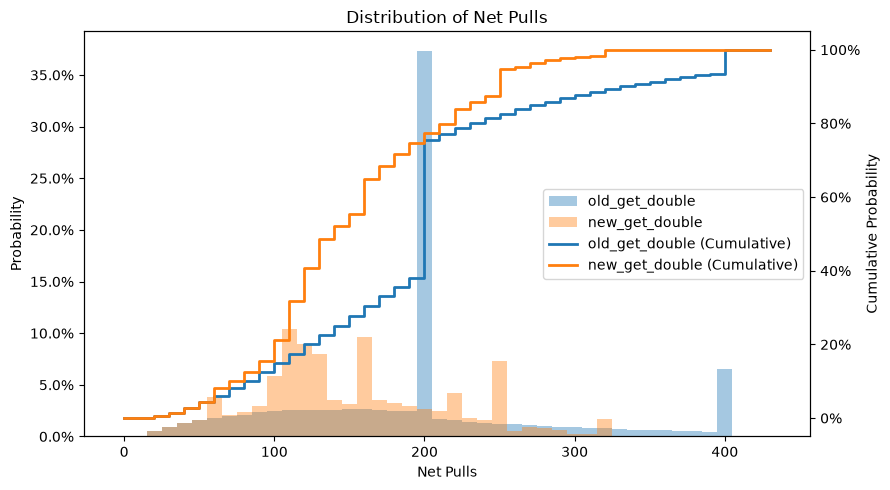

In [111]:
# ============================================================
# 2つの実験結果をグラフで比較するセルです。
# 比較する実験用セルを先に実行してから、このセルを実行してください。
#
# 主に変更する項目
# exp_tag_1 / exp_tag_2: 比較する実験名です。
# x_axis_min / x_axis_max: 横軸の表示範囲です。
# x_bin_width: ヒストグラムの区切り幅です。
#
# 現在の横軸は、募集チケット特典を差し引いた平均実質ガチャ数です。
# 棒グラフが各区間の割合、折れ線が累積確率を表します。
# ============================================================
exp_tag_1 = "old_get_double"
exp_tag_2 = "new_get_double"

pull_counts_1 = [
    result.state.cost_pyroxene / 120
    for result in results_dict[exp_tag_1]
]

pull_counts_2 = [
    result.state.cost_pyroxene / 120
    for result in results_dict[exp_tag_2]
]

plot_distribution(
    pull_counts_1,
    pull_counts_2,
    label_1=exp_tag_1,
    label_2=exp_tag_2,
    x_label="Net Pulls",
    x_axis_min = 0,
    x_axis_max = 450,
    x_bin_width = 10
)